<p style="font-family: Cambria; font-size: 30px;"><b>Prescriptive Analysis</b></p>

In [1]:
#Importing all the Necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import seaborn as sns
from pathlib import Path
import warnings
warnings.simplefilter("ignore", UserWarning)

In [2]:
df = Path( r"C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data")

<p style="font-family: Cambria; font-size: 16px;"><b>Resource Allocation Protocol

<p style="font-family: Cambria; font-size: 16px;"><b>Question 1:</b></p>How should hospitals decide which medical specialists care for each patient based on how bad their heart failure and other health problems are(based on patient NYHA Class and comorbidity burden)?"

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p>  Allocating specialized multidisciplinary care teams evenly across all heart failure patients wastes high-cost clinical resources. Stratifying assignments based on NYHA functional class and Charlson Comorbidity Index (CCI) optimizes high-touch intervention deployment.

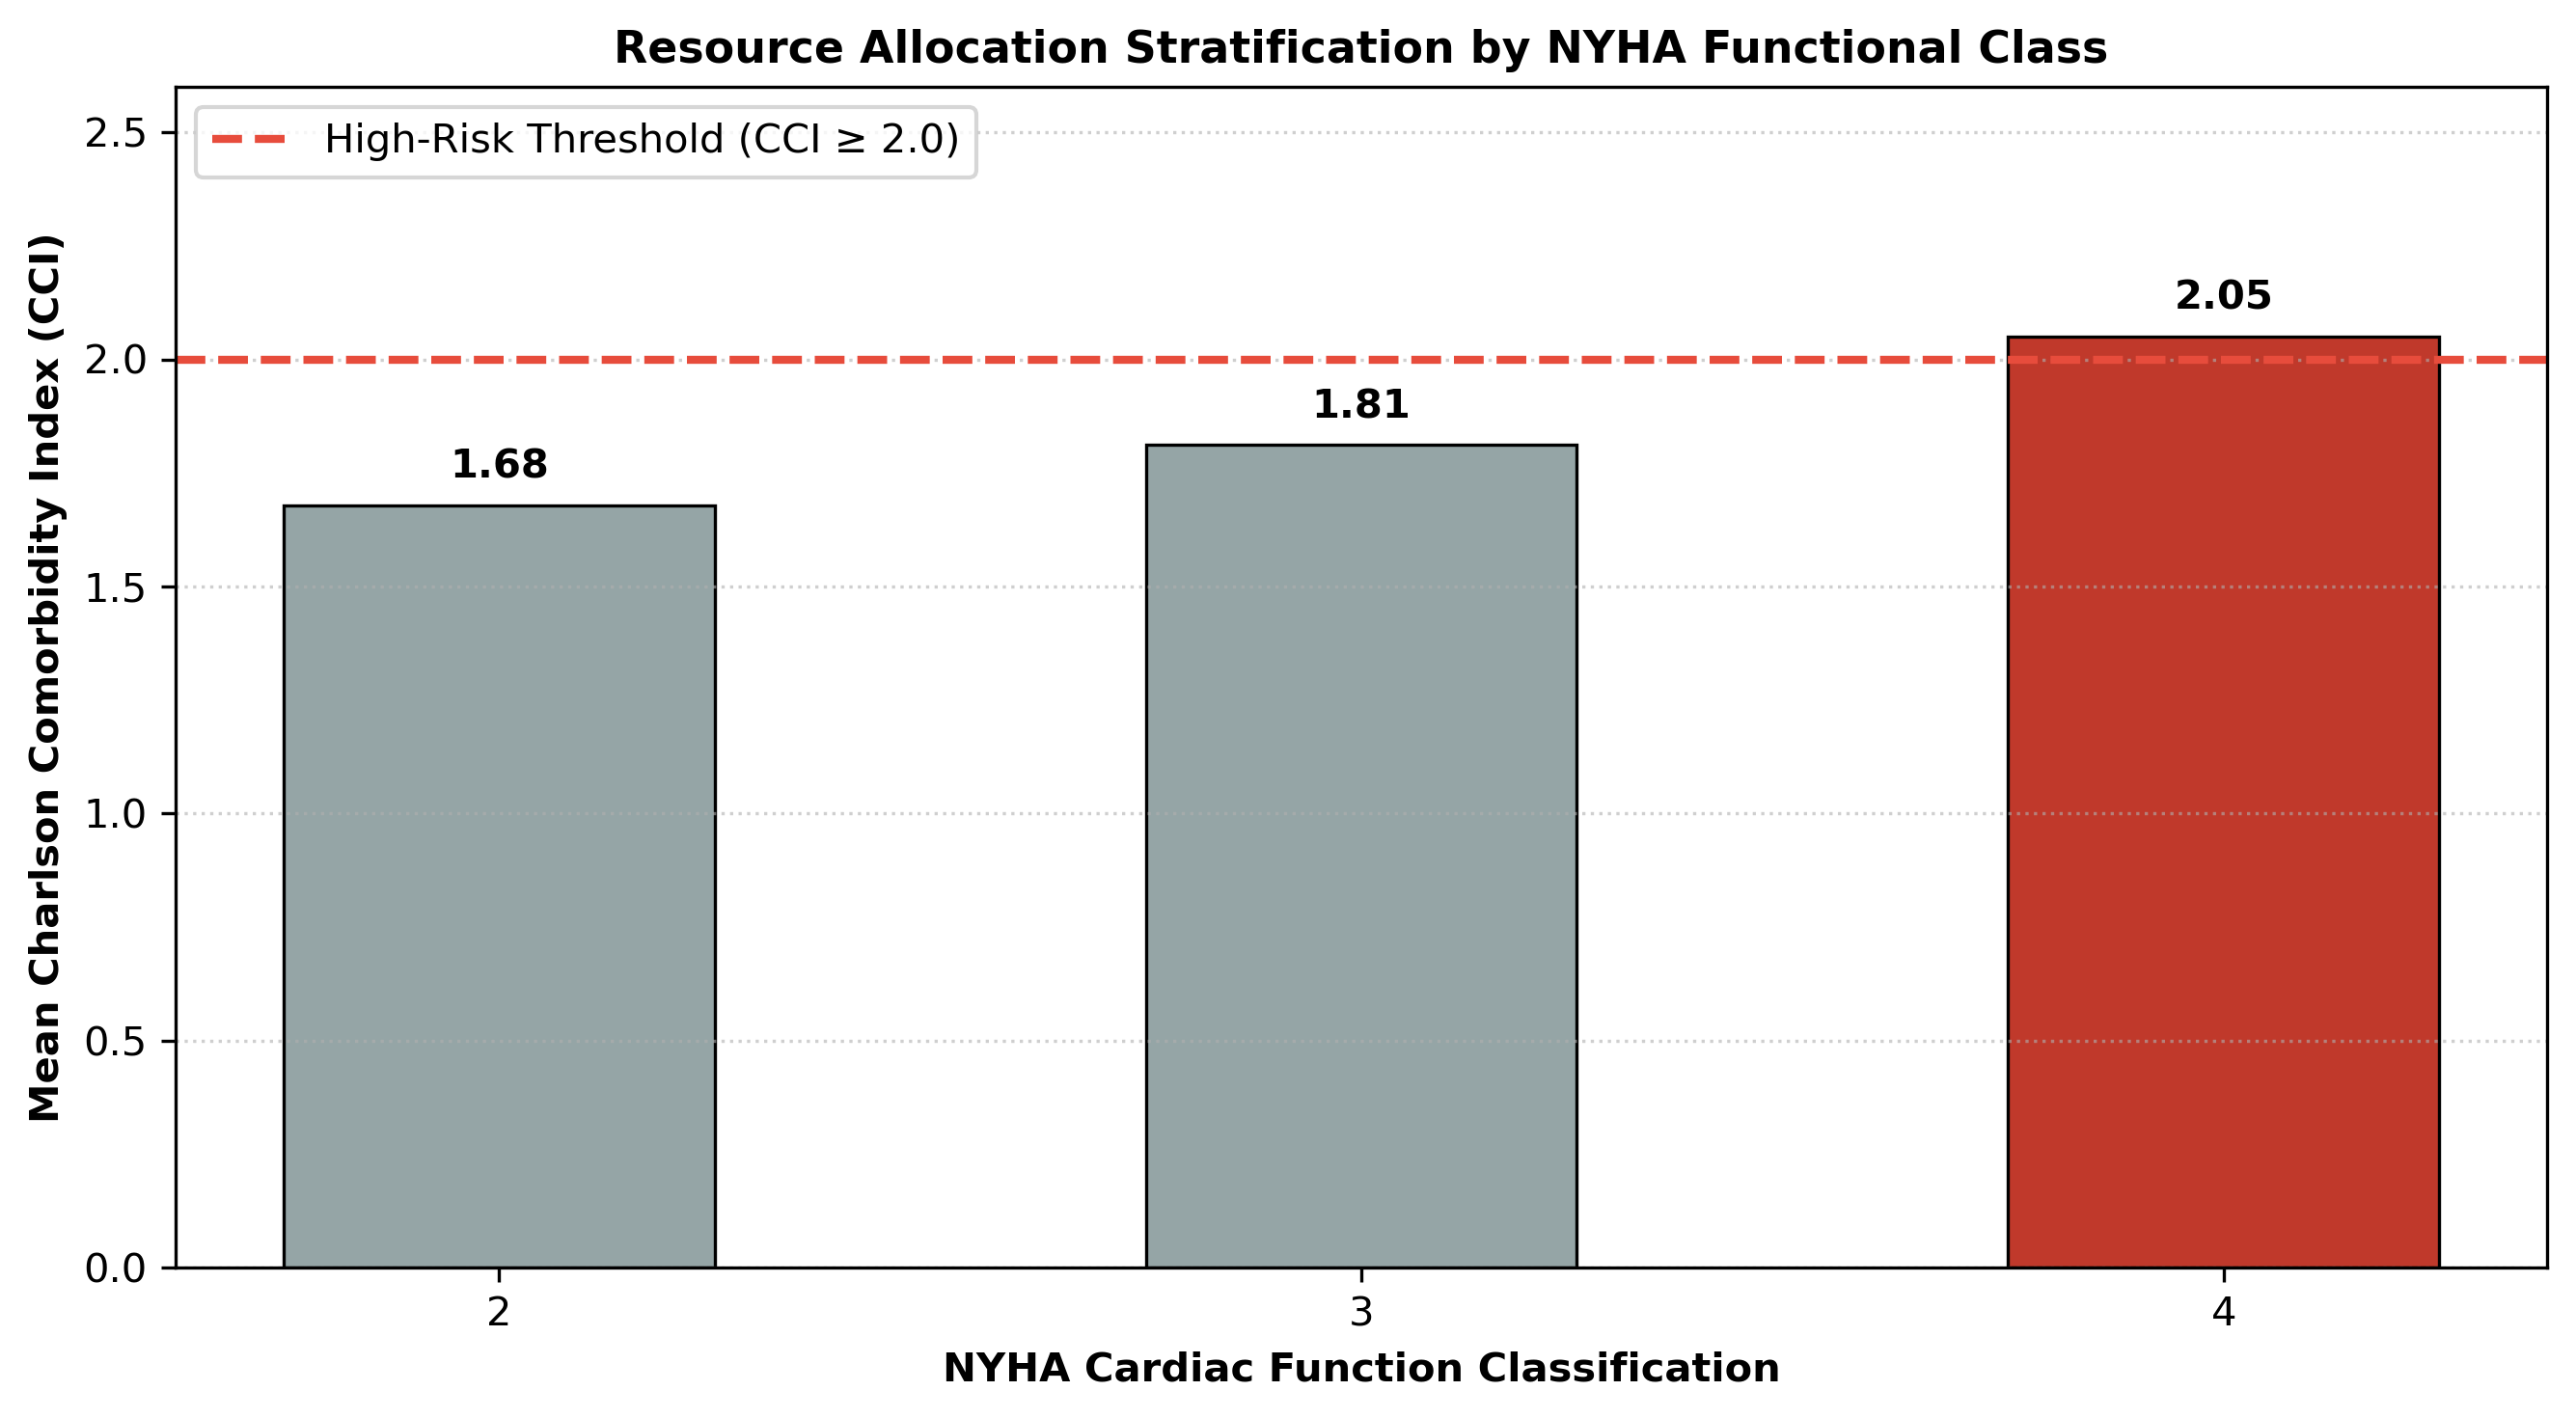

In [12]:
# Calculate mean CCI per NYHA class
q1_data = (
    df.groupby('nyha_cardiac_function_classification')['cci_score']
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5), dpi=300)

# Main Bar Plot with Highlight on Class 4
colors = [
    '#95a5a6' if x < 4 else '#c0392b'
    for x in q1_data['nyha_cardiac_function_classification']
]
bars = plt.bar(
    q1_data['nyha_cardiac_function_classification'].astype(str),
    q1_data['cci_score'],
    color=colors,
    width=0.5,
    edgecolor='black',
    linewidth=0.8,
)

# Threshold Line for High Risk Intervention
plt.axhline(
    y=2.0,
    color='#e74c3c',
    linestyle='--',
    linewidth=2,
    label='High-Risk Threshold (CCI ≥ 2.0)',
)

# Text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 0.04,
        f'{yval:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=10,
    )

plt.title(
    'Resource Allocation Stratification by NYHA Functional Class',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('NYHA Cardiac Function Classification', fontweight='bold')
plt.ylabel('Mean Charlson Comorbidity Index (CCI)', fontweight='bold')
plt.ylim(0, 2.6)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>Patients in NYHA Class 4 present a significantly higher comorbidity burden (mean CCI: 2.05) compared to Class 2 (mean CCI: 1.68).

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p> Automatically assign complex care management and dedicated clinical pharmacist consultations to all NYHA Class 4 patients upon admission.

<p style="font-family: Cambria; font-size: 16px;"><b>Respiratory Support Intervention Thresholds

<p style="font-family: Cambria; font-size: 16px;"><b>Question 2:</b></p>Which patient demographic cohorts require mandatory baseline arterial blood gas (ABG) screening for early non-invasive ventilation (NIV)?

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p> Type II respiratory failure (hypercapnic failure) requires early non-invasive positive pressure ventilation to prevent ICU admission and intubation.

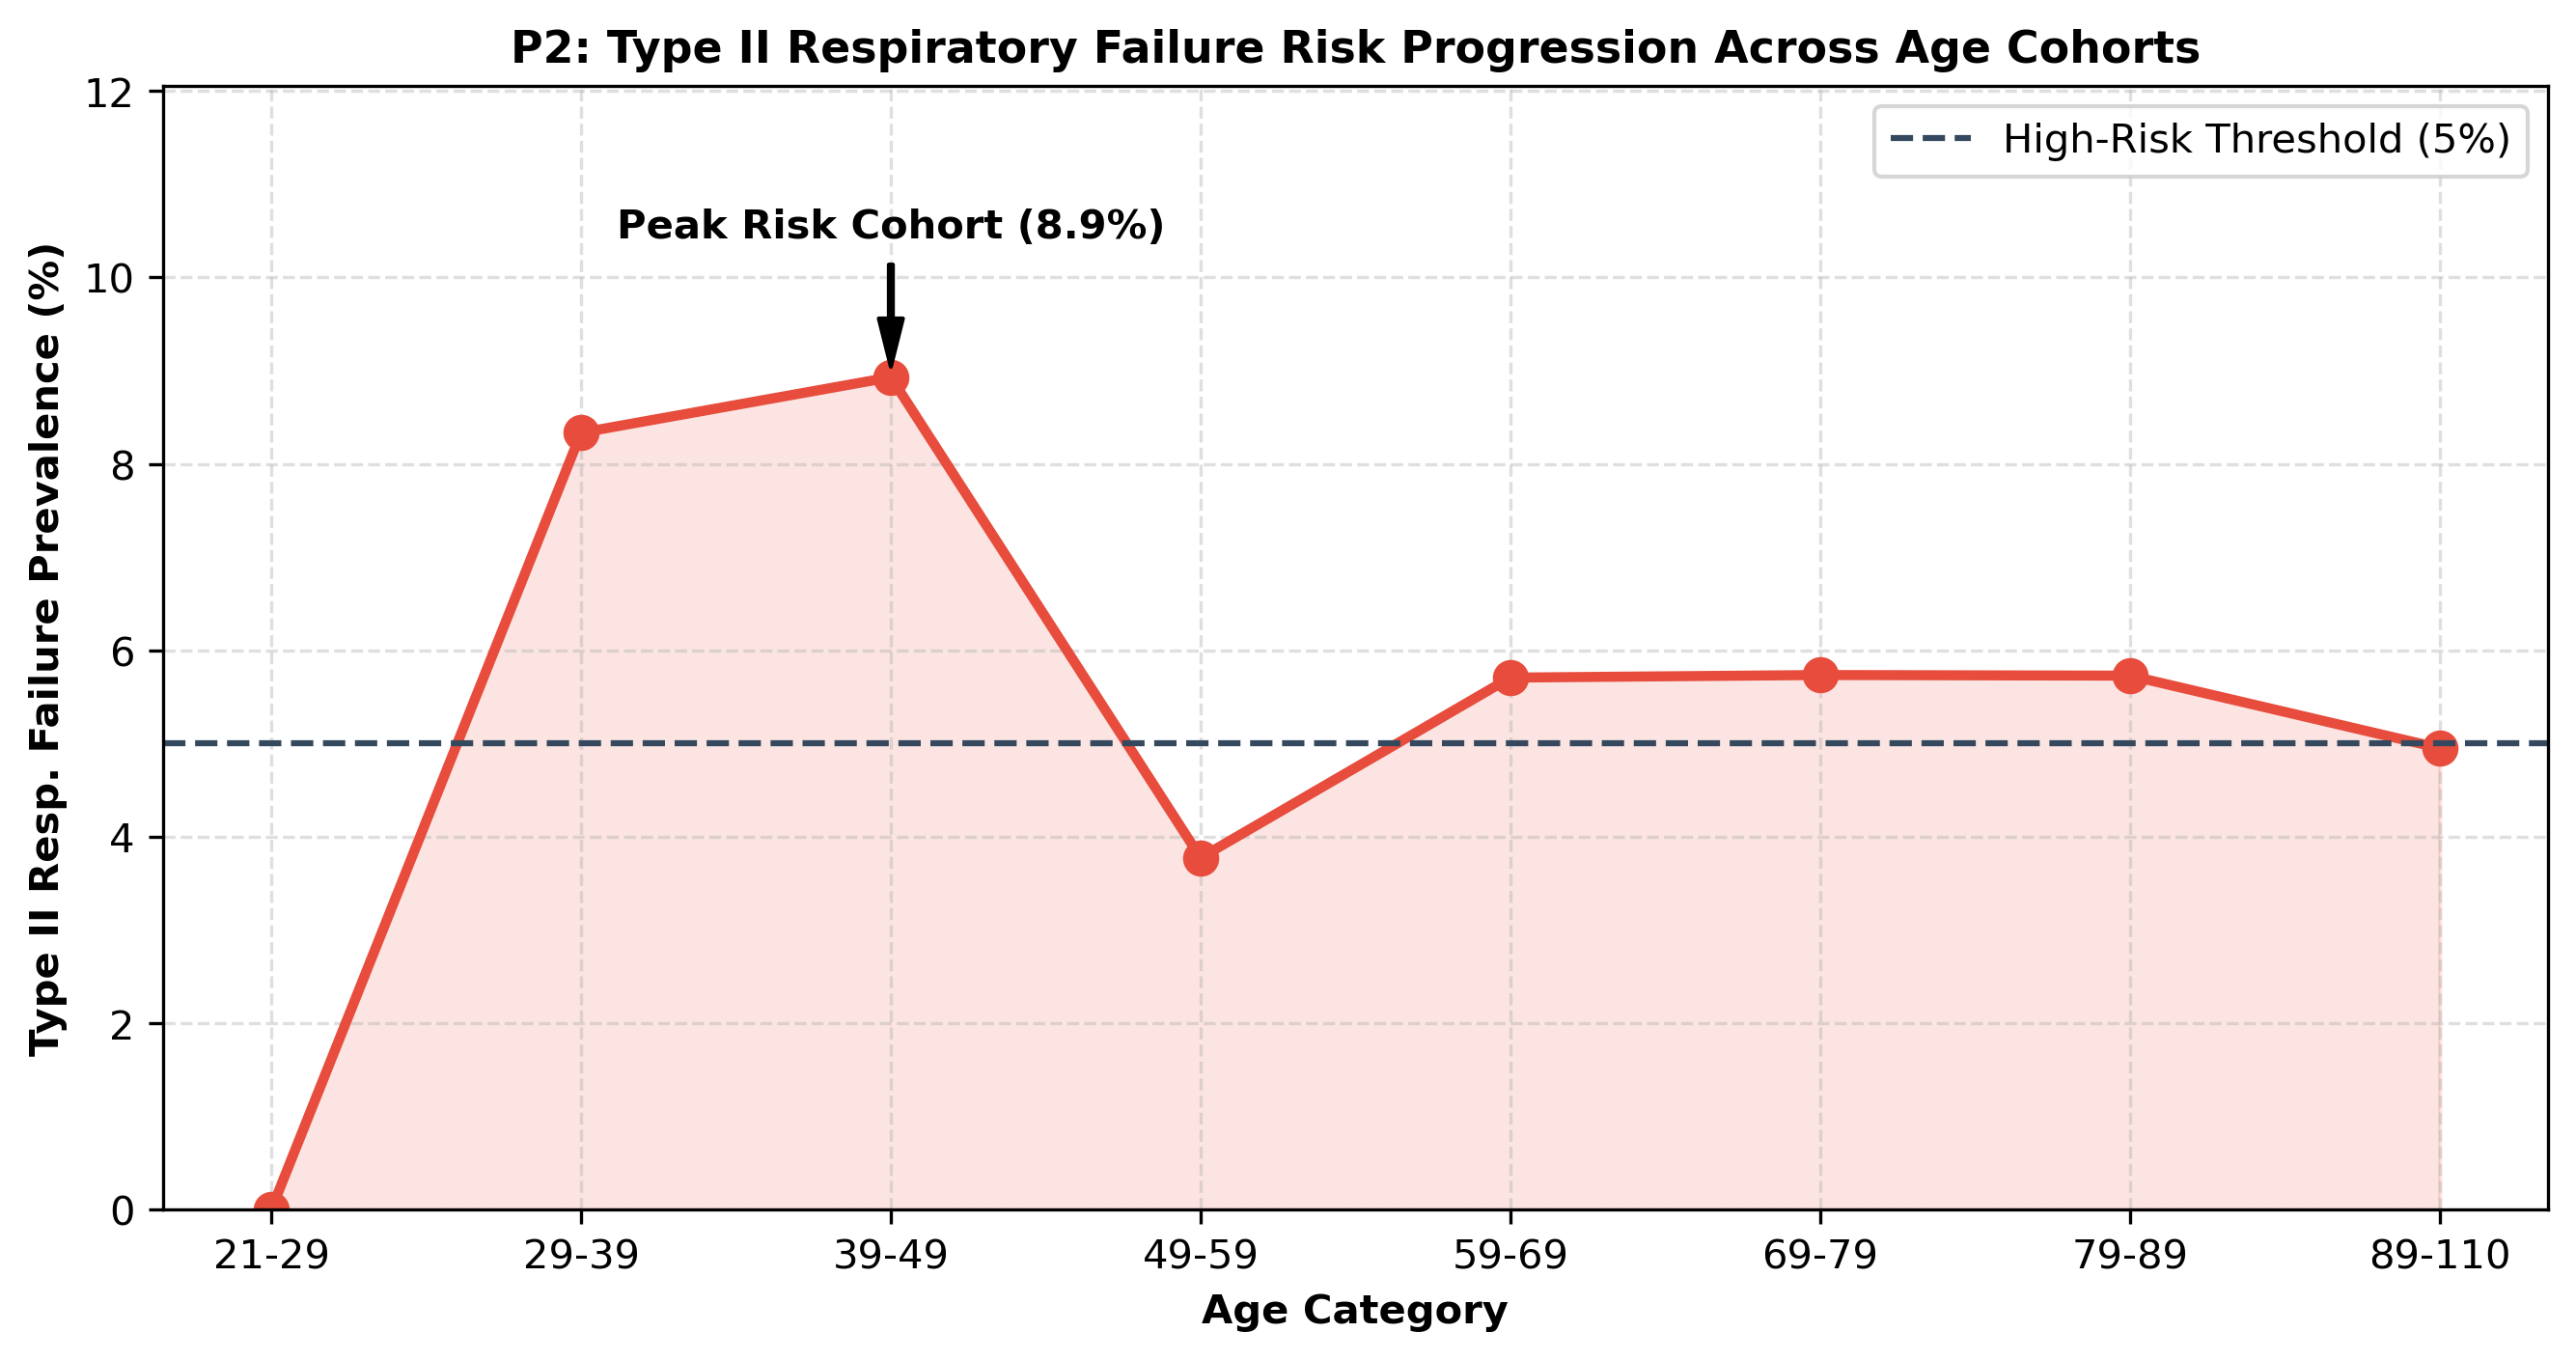

In [14]:
df['typeii_num'] = (df['type_ii_respiratory_failure'] == 'typeii').astype(int)
q2_data = df.groupby('agecat')['typeii_num'].mean() * 100

plt.figure(figsize=(9, 4.8), dpi=300)

# Plot filled area curve
plt.plot(
    q2_data.index,
    q2_data.values,
    color='#e74c3c',
    marker='o',
    linewidth=2.5,
    markersize=8,
)
plt.fill_between(
    q2_data.index, q2_data.values, color='#e74c3c', alpha=0.15
)

# Mandatory Threshold Line
plt.axhline(
    y=5.0,
    color='#34495e',
    linestyle='--',
    linewidth=1.5,
    label='High-Risk Threshold (5%)',
)

# Highlight Peak Risk Cohort
peak_age = q2_data.idxmax()
peak_val = q2_data.max()
plt.annotate(
    f'Peak Risk Cohort ({peak_val:.1f}%)',
    xy=(peak_age, peak_val),
    xytext=(peak_age, peak_val + 1.5),
    arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
    fontweight='bold',
    ha='center',
)

plt.title(
    'P2: Type II Respiratory Failure Risk Progression Across Age Cohorts',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('Age Category', fontweight='bold')
plt.ylabel('Type II Resp. Failure Prevalence (%)', fontweight='bold')
plt.ylim(0, peak_val * 1.35)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>Patients aged 39–49 exhibit the highest prevalence rate (8.9%) of Type II Respiratory Failure, remaining elevated above 5% across older age brackets.

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p>Establish a mandatory clinical protocol requiring automated ABG testing and pulmonology consultation for all heart failure admissions presenting with dyspnea aged 30+.

<p style="font-family: Cambria; font-size: 16px;"><b>Cardio-Renal Risk Triage System

<p style="font-family: Cambria; font-size: 16px;"><b>Question 3:</b></p>At what age should kidney doctors(nephrologist) automatically start helping take care of heart patients in the hospital?"

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p> Acute kidney injury and chronic kidney disease (CKD) severely limit heart failure medication options (e.g., ACEi, ARB, aldosterone antagonists).

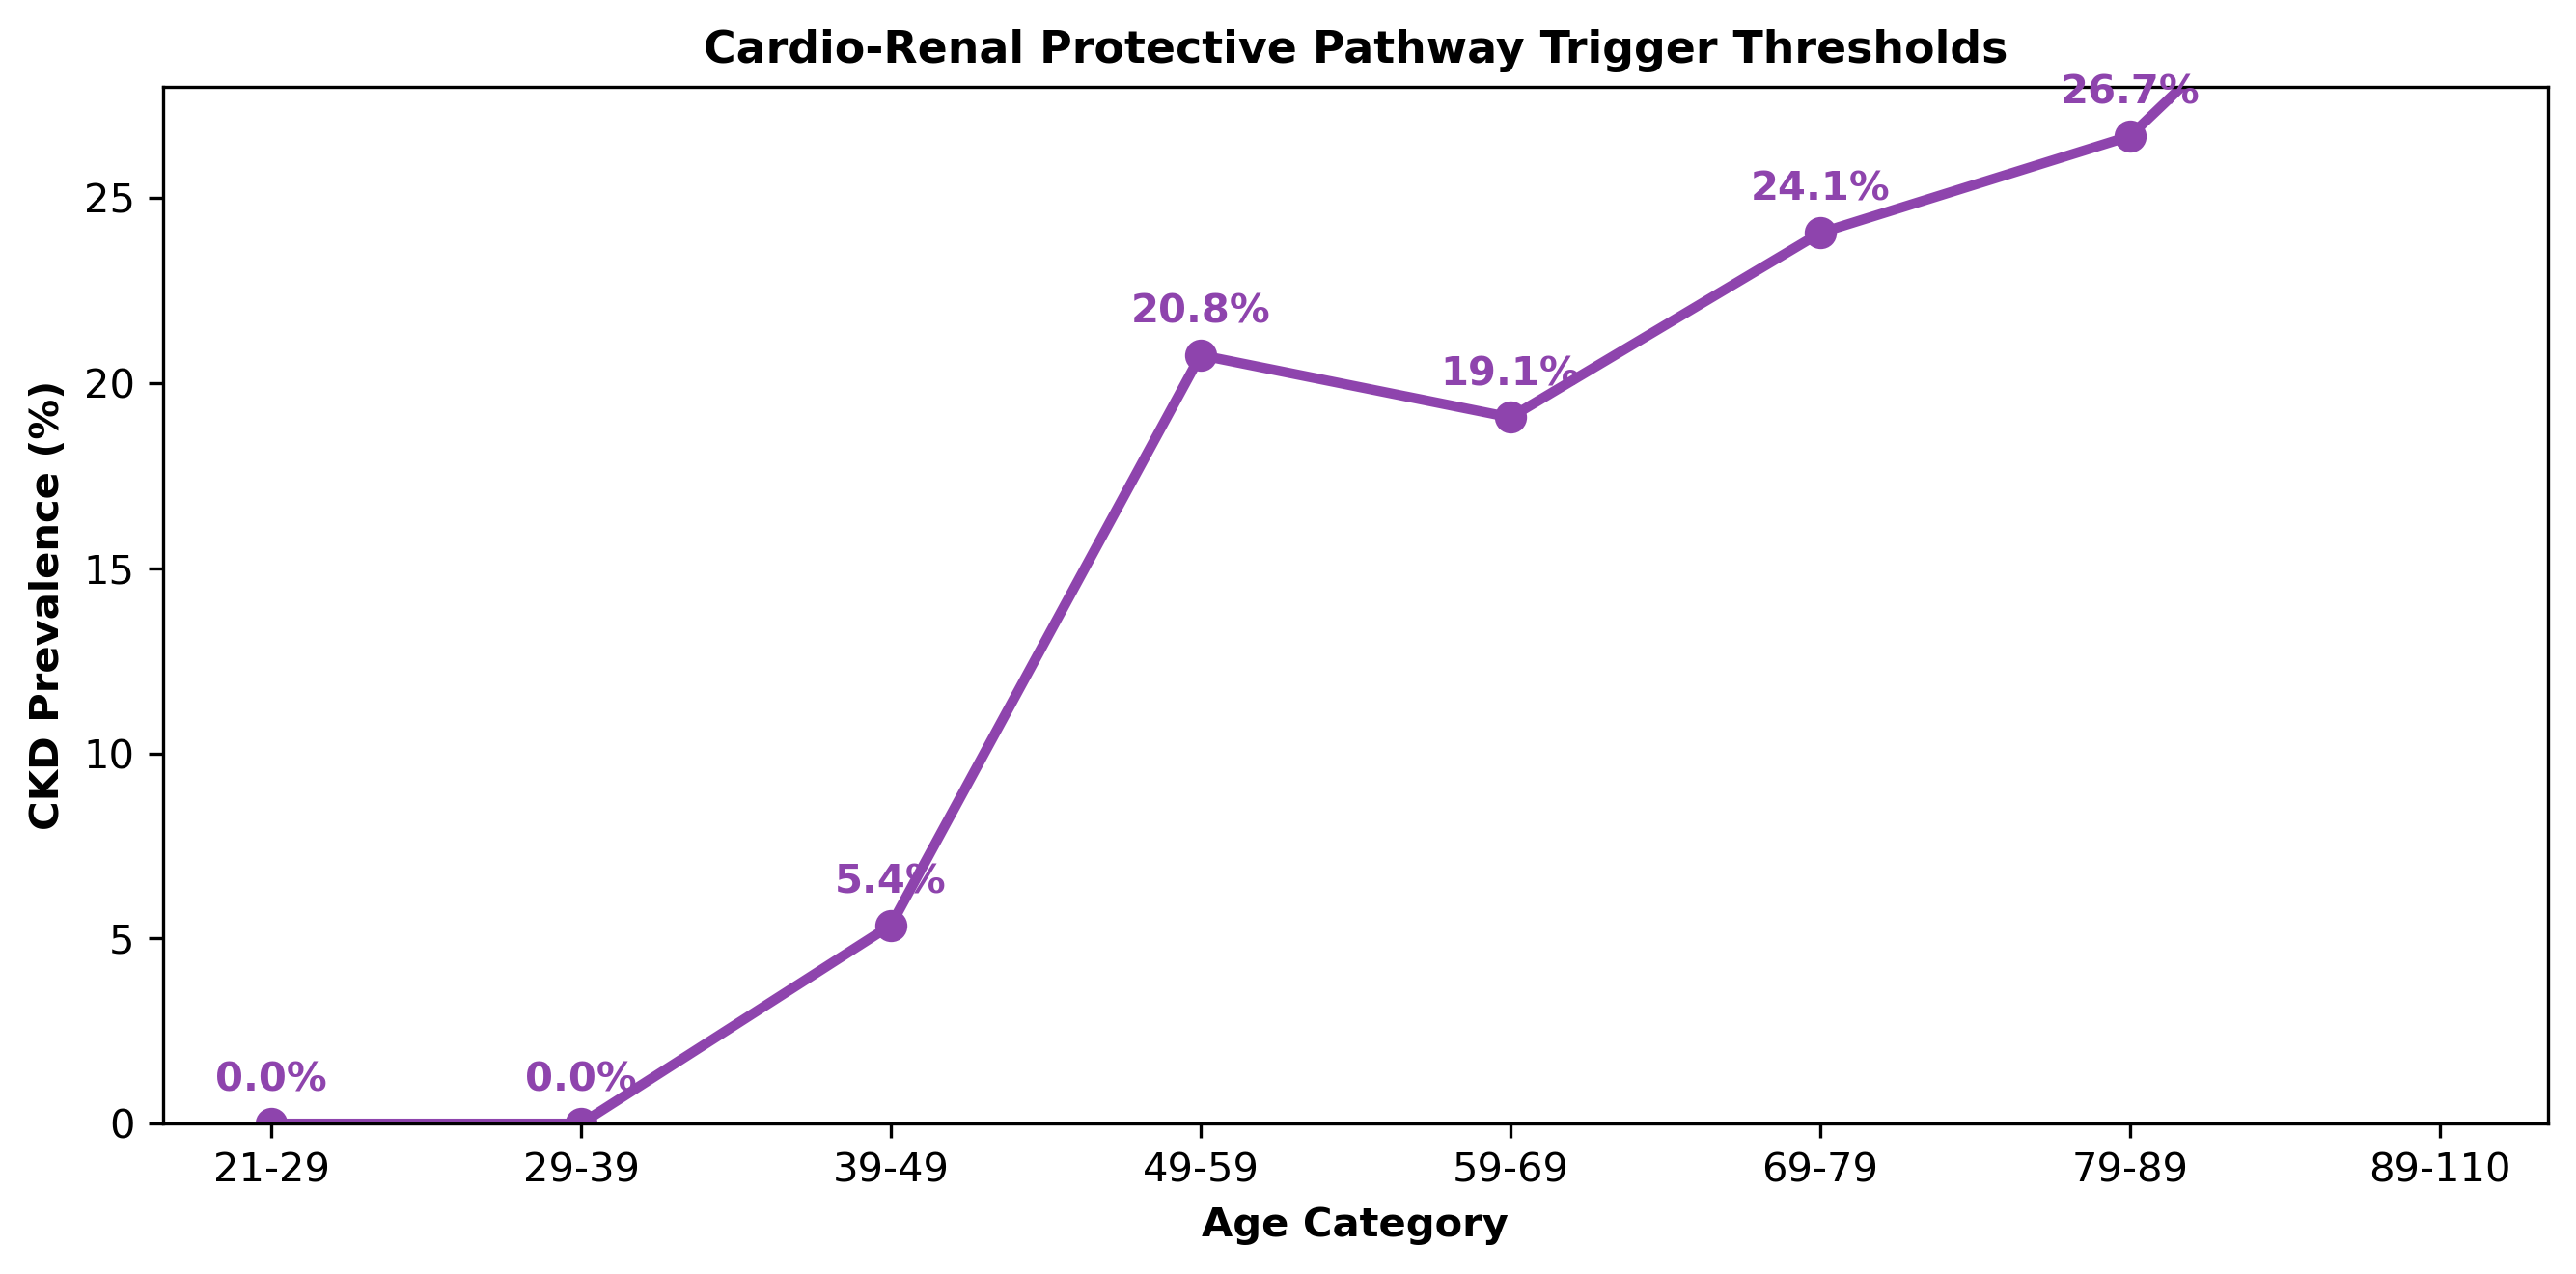

In [6]:
# Prescriptive Action Code - Q4
q4_data = (
    df.groupby('agecat')['moderate_to_severe_chronic_kidney_disease'].mean()
    * 100
)

plt.figure(figsize=(9, 4.5), dpi=300)
plt.plot(
    q4_data.index,
    q4_data.values,
    marker='o',
    linewidth=2.5,
    color='#8e44ad',
    markersize=7,
)
plt.title(
    'Cardio-Renal Protective Pathway Trigger Thresholds',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('Age Category', fontweight='bold')
plt.ylabel('CKD Prevalence (%)', fontweight='bold')
plt.ylim(0, 28)
for idx, val in zip(q4_data.index, q4_data.values):
  plt.annotate(
      f'{val:.1f}%',
      (idx, val),
      textcoords='offset points',
      xytext=(0, 8),
      ha='center',
      fontweight='bold',
      color='#8e44ad',
  )
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>CKD rates jump from 5.4% in patients aged 39–49 to 20.8% in the 49–59 age bracket, peaking at 24.1% in patients aged 69–79.

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p>Implement automated clinical decision alerts for cardio-renal protocol initiation and baseline serum creatinine monitoring for all cardiac admissions aged 50 and above.

<p style="font-family: Cambria; font-size: 16px;"><b>Acute Hemodynamic Deterioration Escalation Matrix

<p style="font-family: Cambria; font-size: 16px;"><b>Question 4:</b></p>How should a hospital adjust nursing care and monitoring levels for heart patients based on their short-term severity (Killip Grade) and long-term symptom level (NYHA Class)? 

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p>Misinterpreting functional severity (NYHA) as acute hemodynamic stability (Killip Grade) can lead to unexpected ICU transfers.

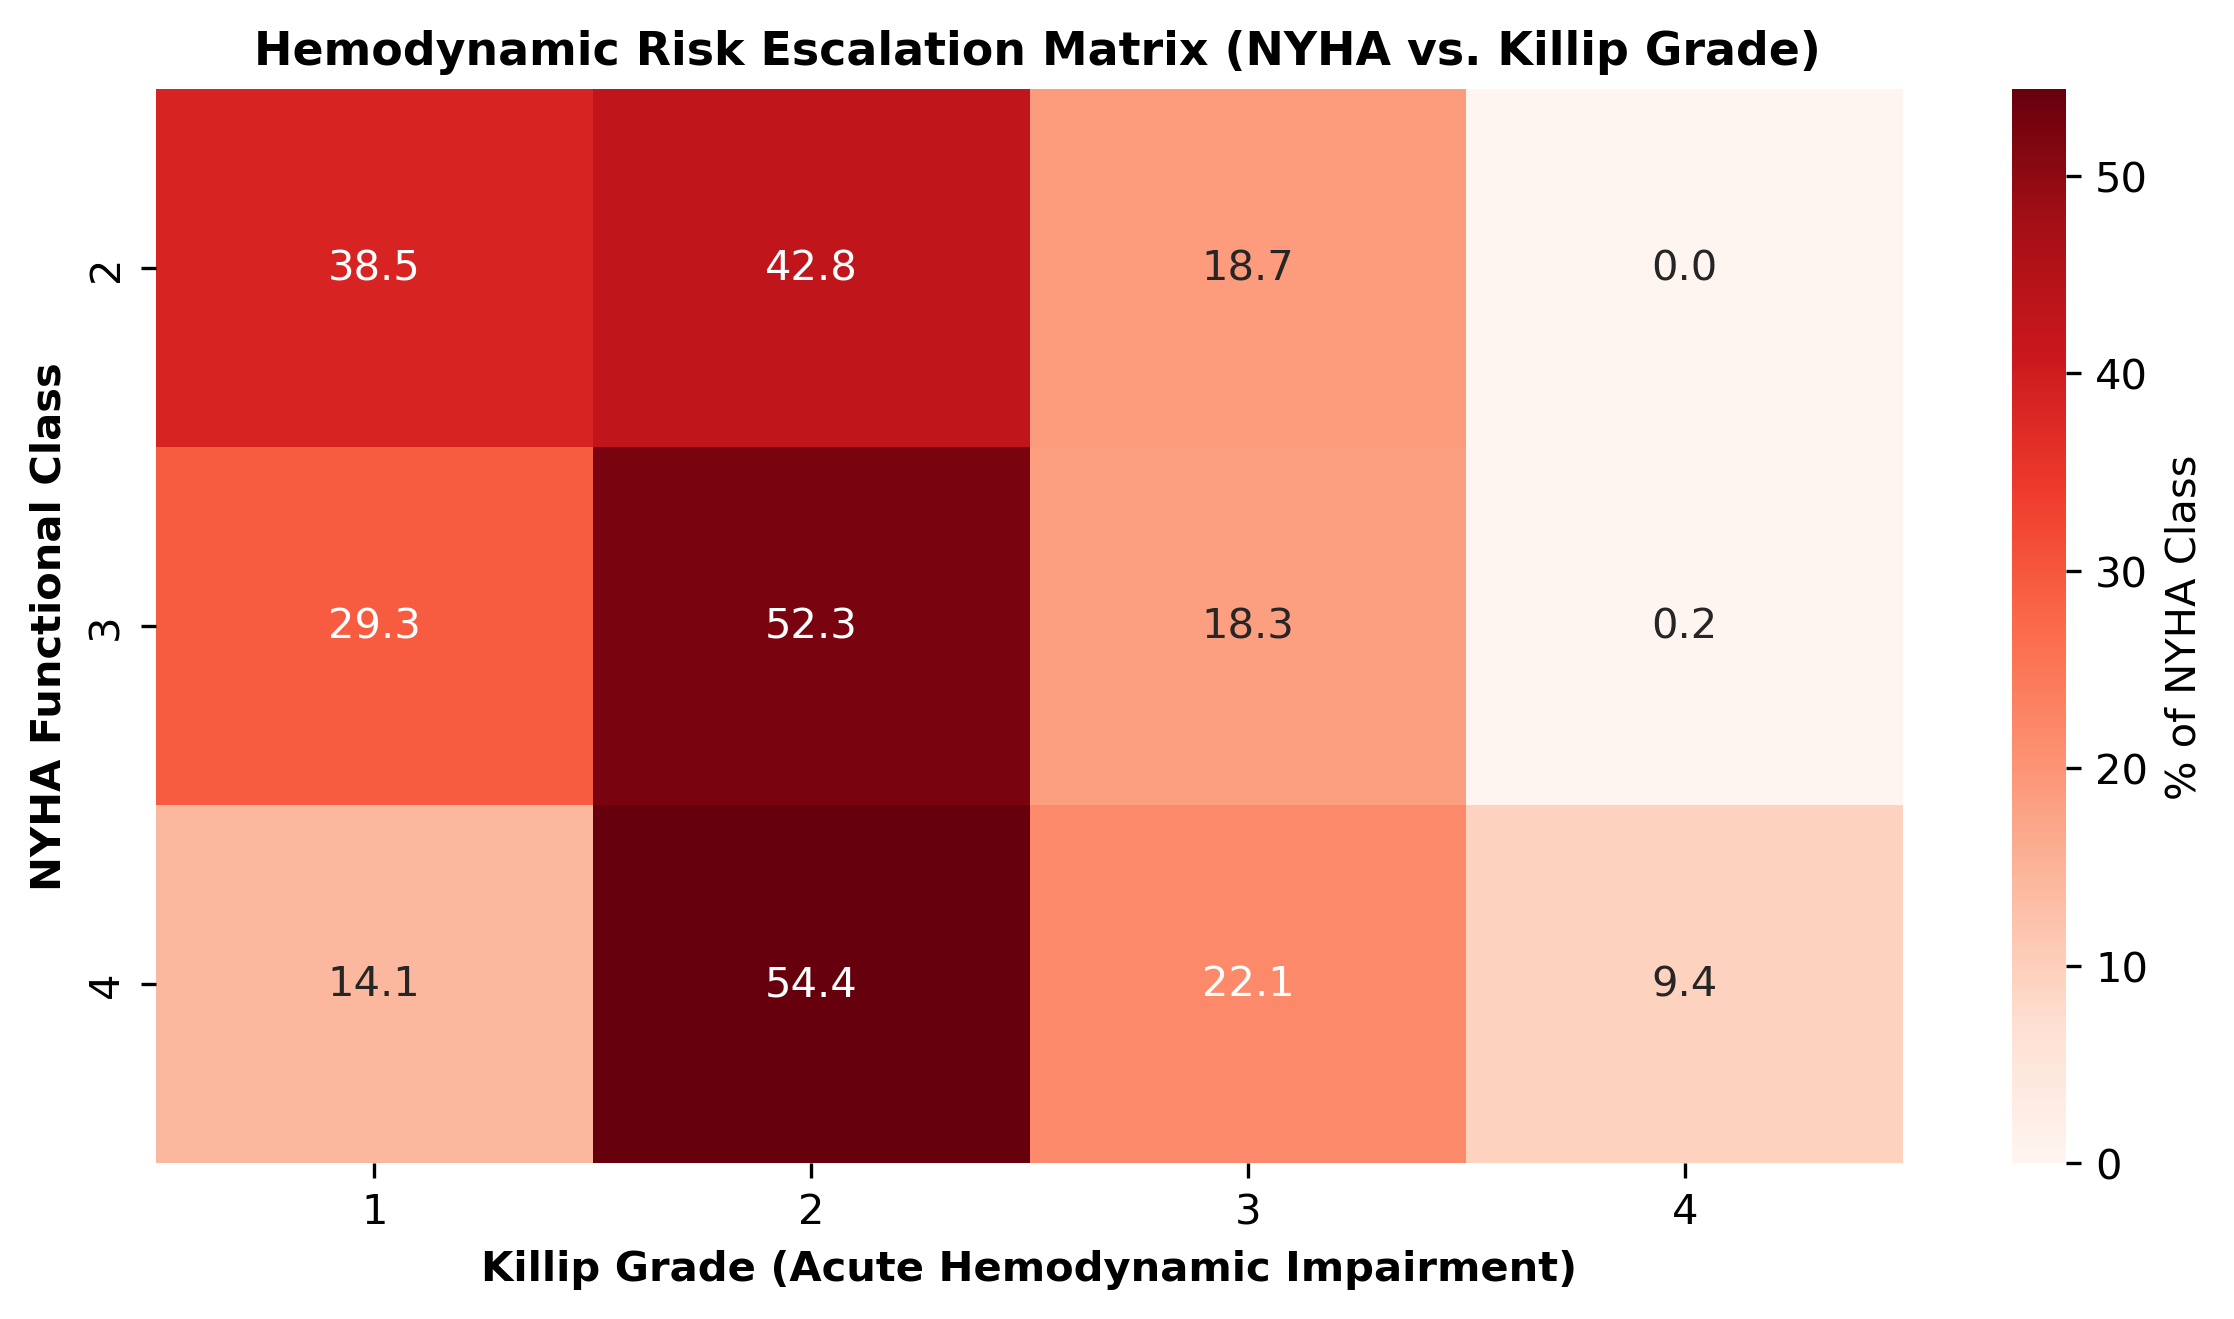

In [7]:
# Prescriptive Action Code - Q5
import seaborn as sns

ct = (
    pd.crosstab(
        df['nyha_cardiac_function_classification'],
        df['killip_grade'],
        normalize='index',
    )
    * 100
)

plt.figure(figsize=(8, 4.5), dpi=300)
sns.heatmap(
    ct,
    annot=True,
    fmt='.1f',
    cmap='Reds',
    cbar_kws={'label': '% of NYHA Class'},
)
plt.title(
    ' Hemodynamic Risk Escalation Matrix (NYHA vs. Killip Grade)',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('Killip Grade (Acute Hemodynamic Impairment)', fontweight='bold')
plt.ylabel('NYHA Functional Class', fontweight='bold')
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>9.4% of NYHA Class 4 patients are in Killip Grade 4 (cardiogenic shock), requiring immediate intensive care monitoring.

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p>Enforce direct ICU/CCU placement rules for any patient with Killip Grade $\ge$ 3, regardless of whether their chronic NYHA class was low.

<p style="font-family: Cambria; font-size: 16px;"><b>Post-Discharge Readmission Prevention Triad Tracking

<p style="font-family: Cambria; font-size: 16px;"><b>Question 5:</b></p>Which combination of health conditions places a heart failure patient at highest risk, requiring a nurse home visit within 48 hours of leaving the hospital?"

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p>Readmissions are often driven by co-occurring systemic diseases rather than primary cardiac conditions alone.

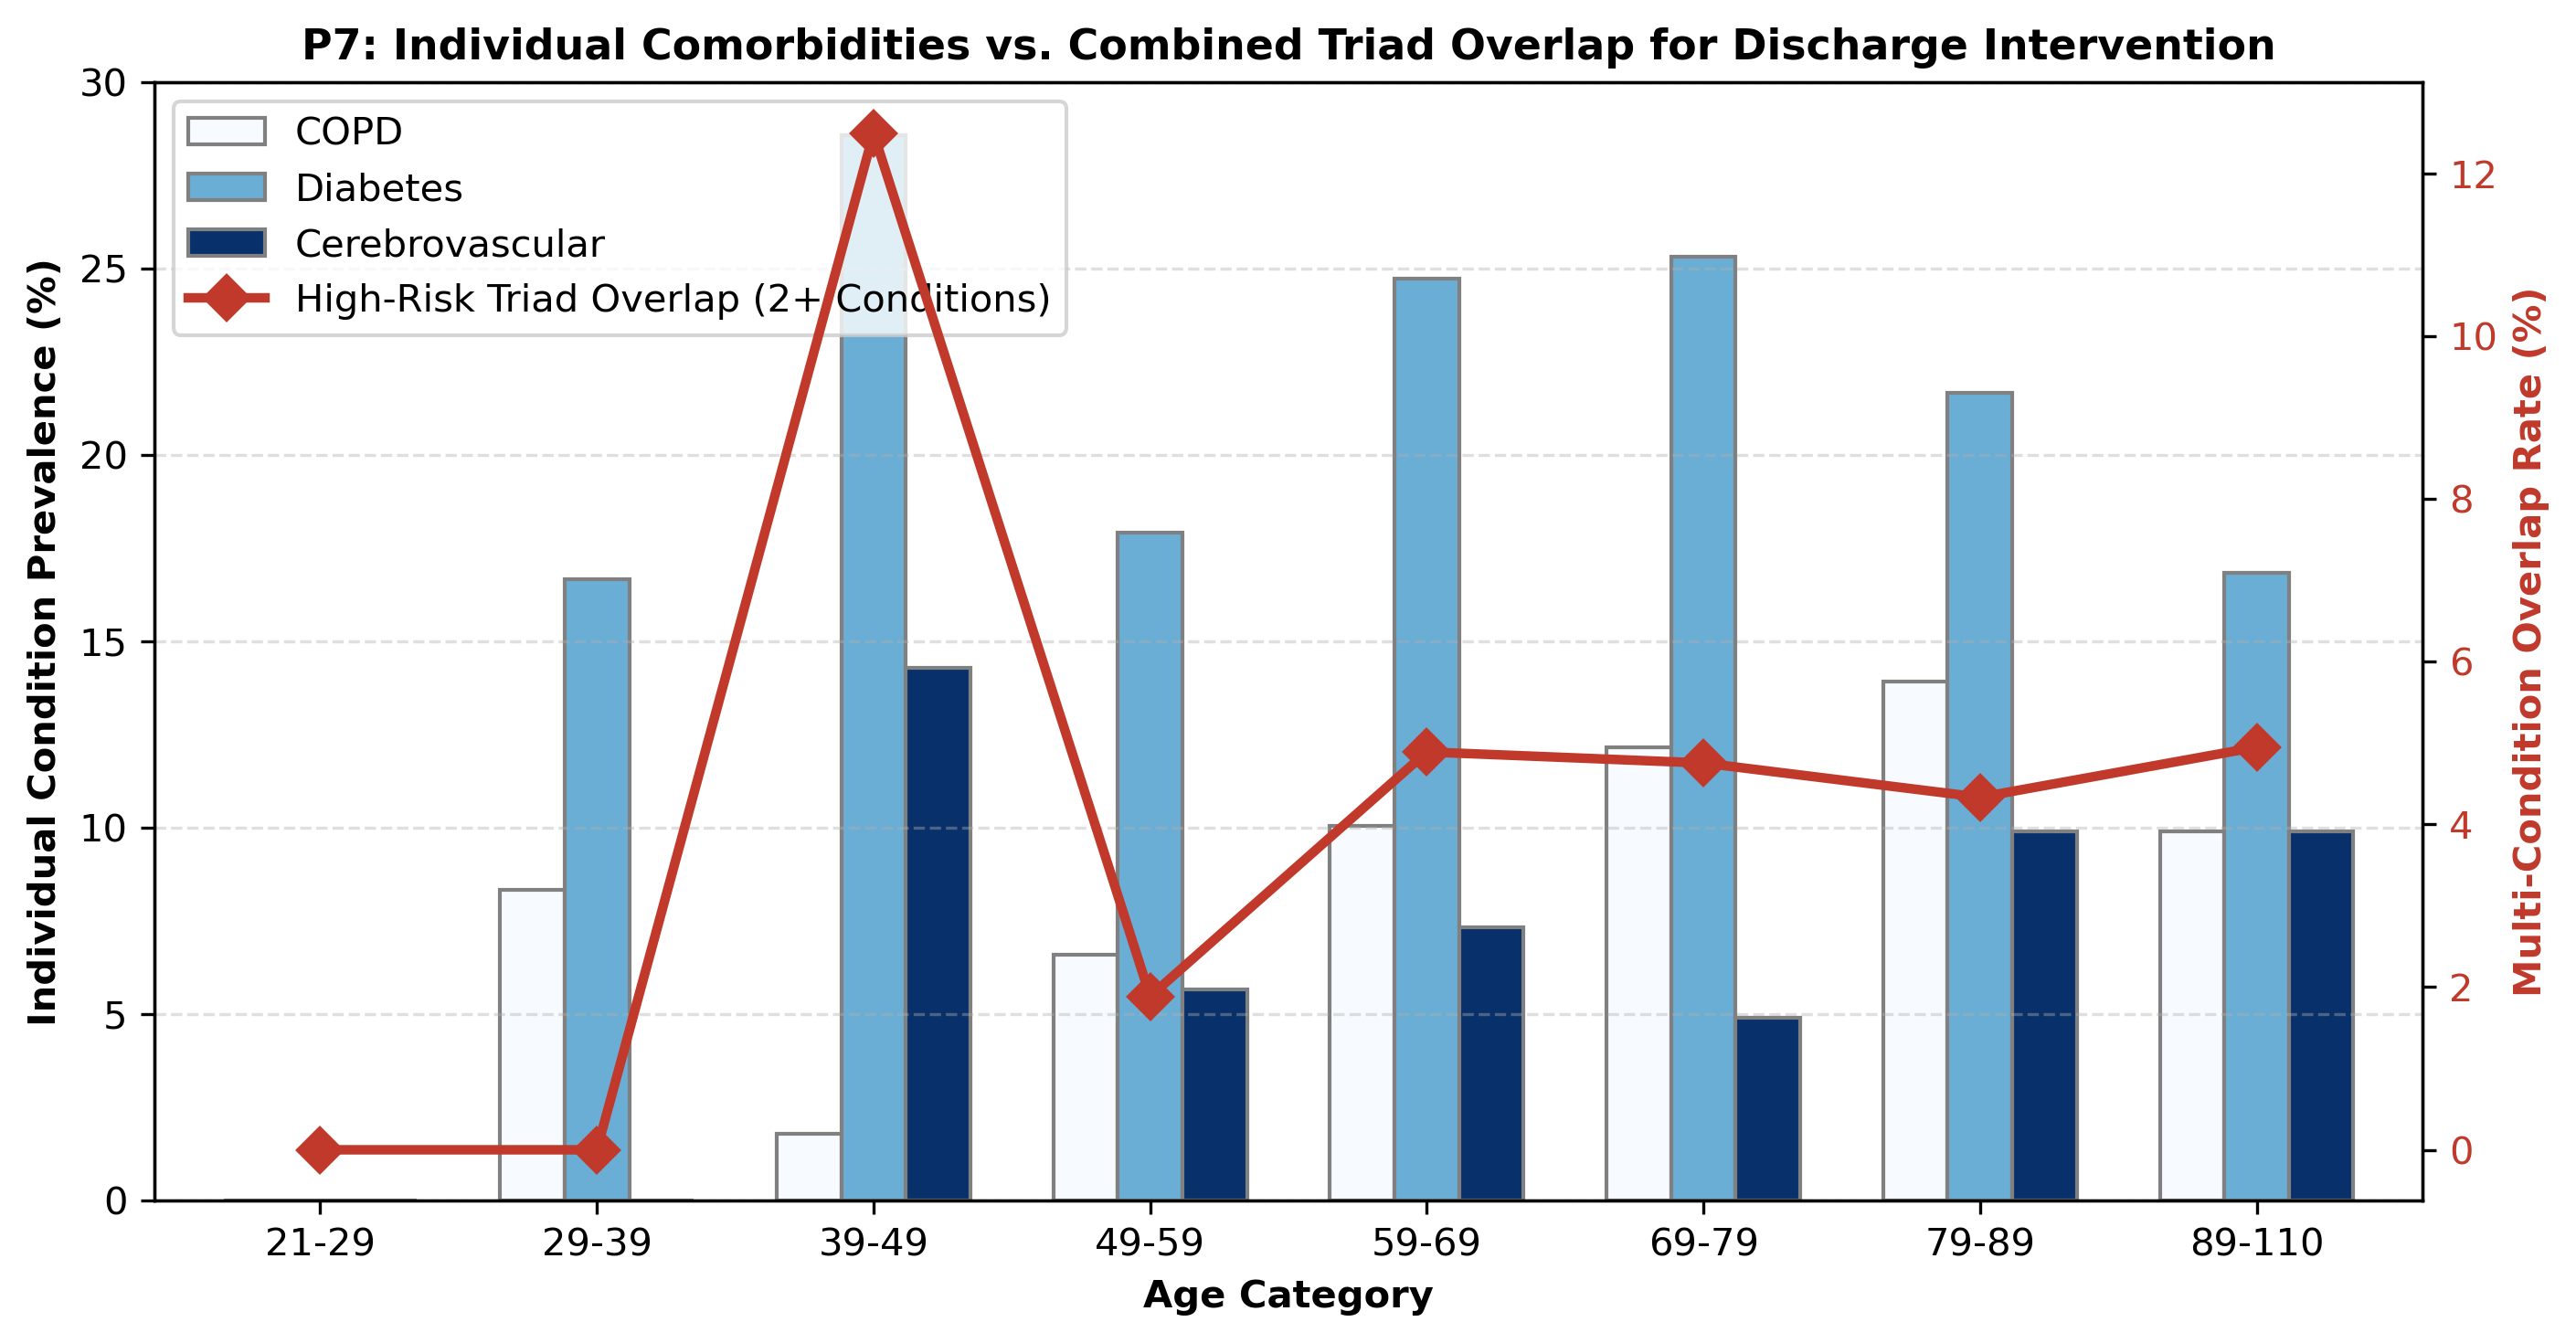

In [16]:
# Calculate individual rates
q7_data = (
    df.groupby('agecat')[
        [
            'chronic_obstructive_pulmonary_disease',
            'diabetes',
            'cerebrovascular_disease',
        ]
    ].mean()
    * 100
)
q7_data.columns = ['COPD', 'Diabetes', 'Cerebrovascular']

# Calculate combined high-risk score (count of active conditions per patient)
df['triad_count'] = (
    df['chronic_obstructive_pulmonary_disease']
    + df['diabetes']
    + df['cerebrovascular_disease']
)
triad_overlap = df.groupby('agecat')['triad_count'].apply(
    lambda x: (x >= 2).mean() * 100
)

fig, ax1 = plt.subplots(figsize=(9.5, 5), dpi=300)

# Primary Axis: Bars for individual conditions
q7_data.plot(kind='bar', ax=ax1, width=0.7, colormap='Blues', edgecolor='gray')
ax1.set_ylabel('Individual Condition Prevalence (%)', fontweight='bold')
ax1.set_xlabel('Age Category', fontweight='bold')
ax1.set_xticklabels(q7_data.index, rotation=0)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Secondary Axis: High-risk overlap line
ax2 = ax1.twinx()
ax2.plot(
    triad_overlap.index,
    triad_overlap.values,
    color='#c0392b',
    marker='D',
    linewidth=2.5,
    markersize=8,
    label='High-Risk Triad Overlap (2+ Conditions)',
)
ax2.set_ylabel(
    'Multi-Condition Overlap Rate (%)', fontweight='bold', color='#c0392b'
)
ax2.tick_params(axis='y', labelcolor='#c0392b')

plt.title(
    'P7: Individual Comorbidities vs. Combined Triad Overlap for Discharge Intervention',
    fontsize=11,
    fontweight='bold',
)

# Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>Diabetes peaks at 28.6% in middle-aged cohorts (39–49), while COPD steadily increases with age, reaching 13.9% in patients aged 79–89.

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p>Trigger mandatory post-discharge home health visits within 48 hours for any patient presenting with the "Triad Risk" (Heart Failure + Diabetes + COPD).

<p style="font-family: Cambria; font-size: 16px;"><b>Gender-Specific Clinical Management Guidelines

<p style="font-family: Cambria; font-size: 16px;"><b>Question 6:</b></p>How should treatment plans for left, right, or double-sided heart failure be tailored for male versus female patients?

<p style="font-family: Cambria; font-size: 16px;"><b>Clinical Reasoning:</b></p>Biological sex differences influence heart failure presentation, vascular compliance, and response to cardiac therapeutics.

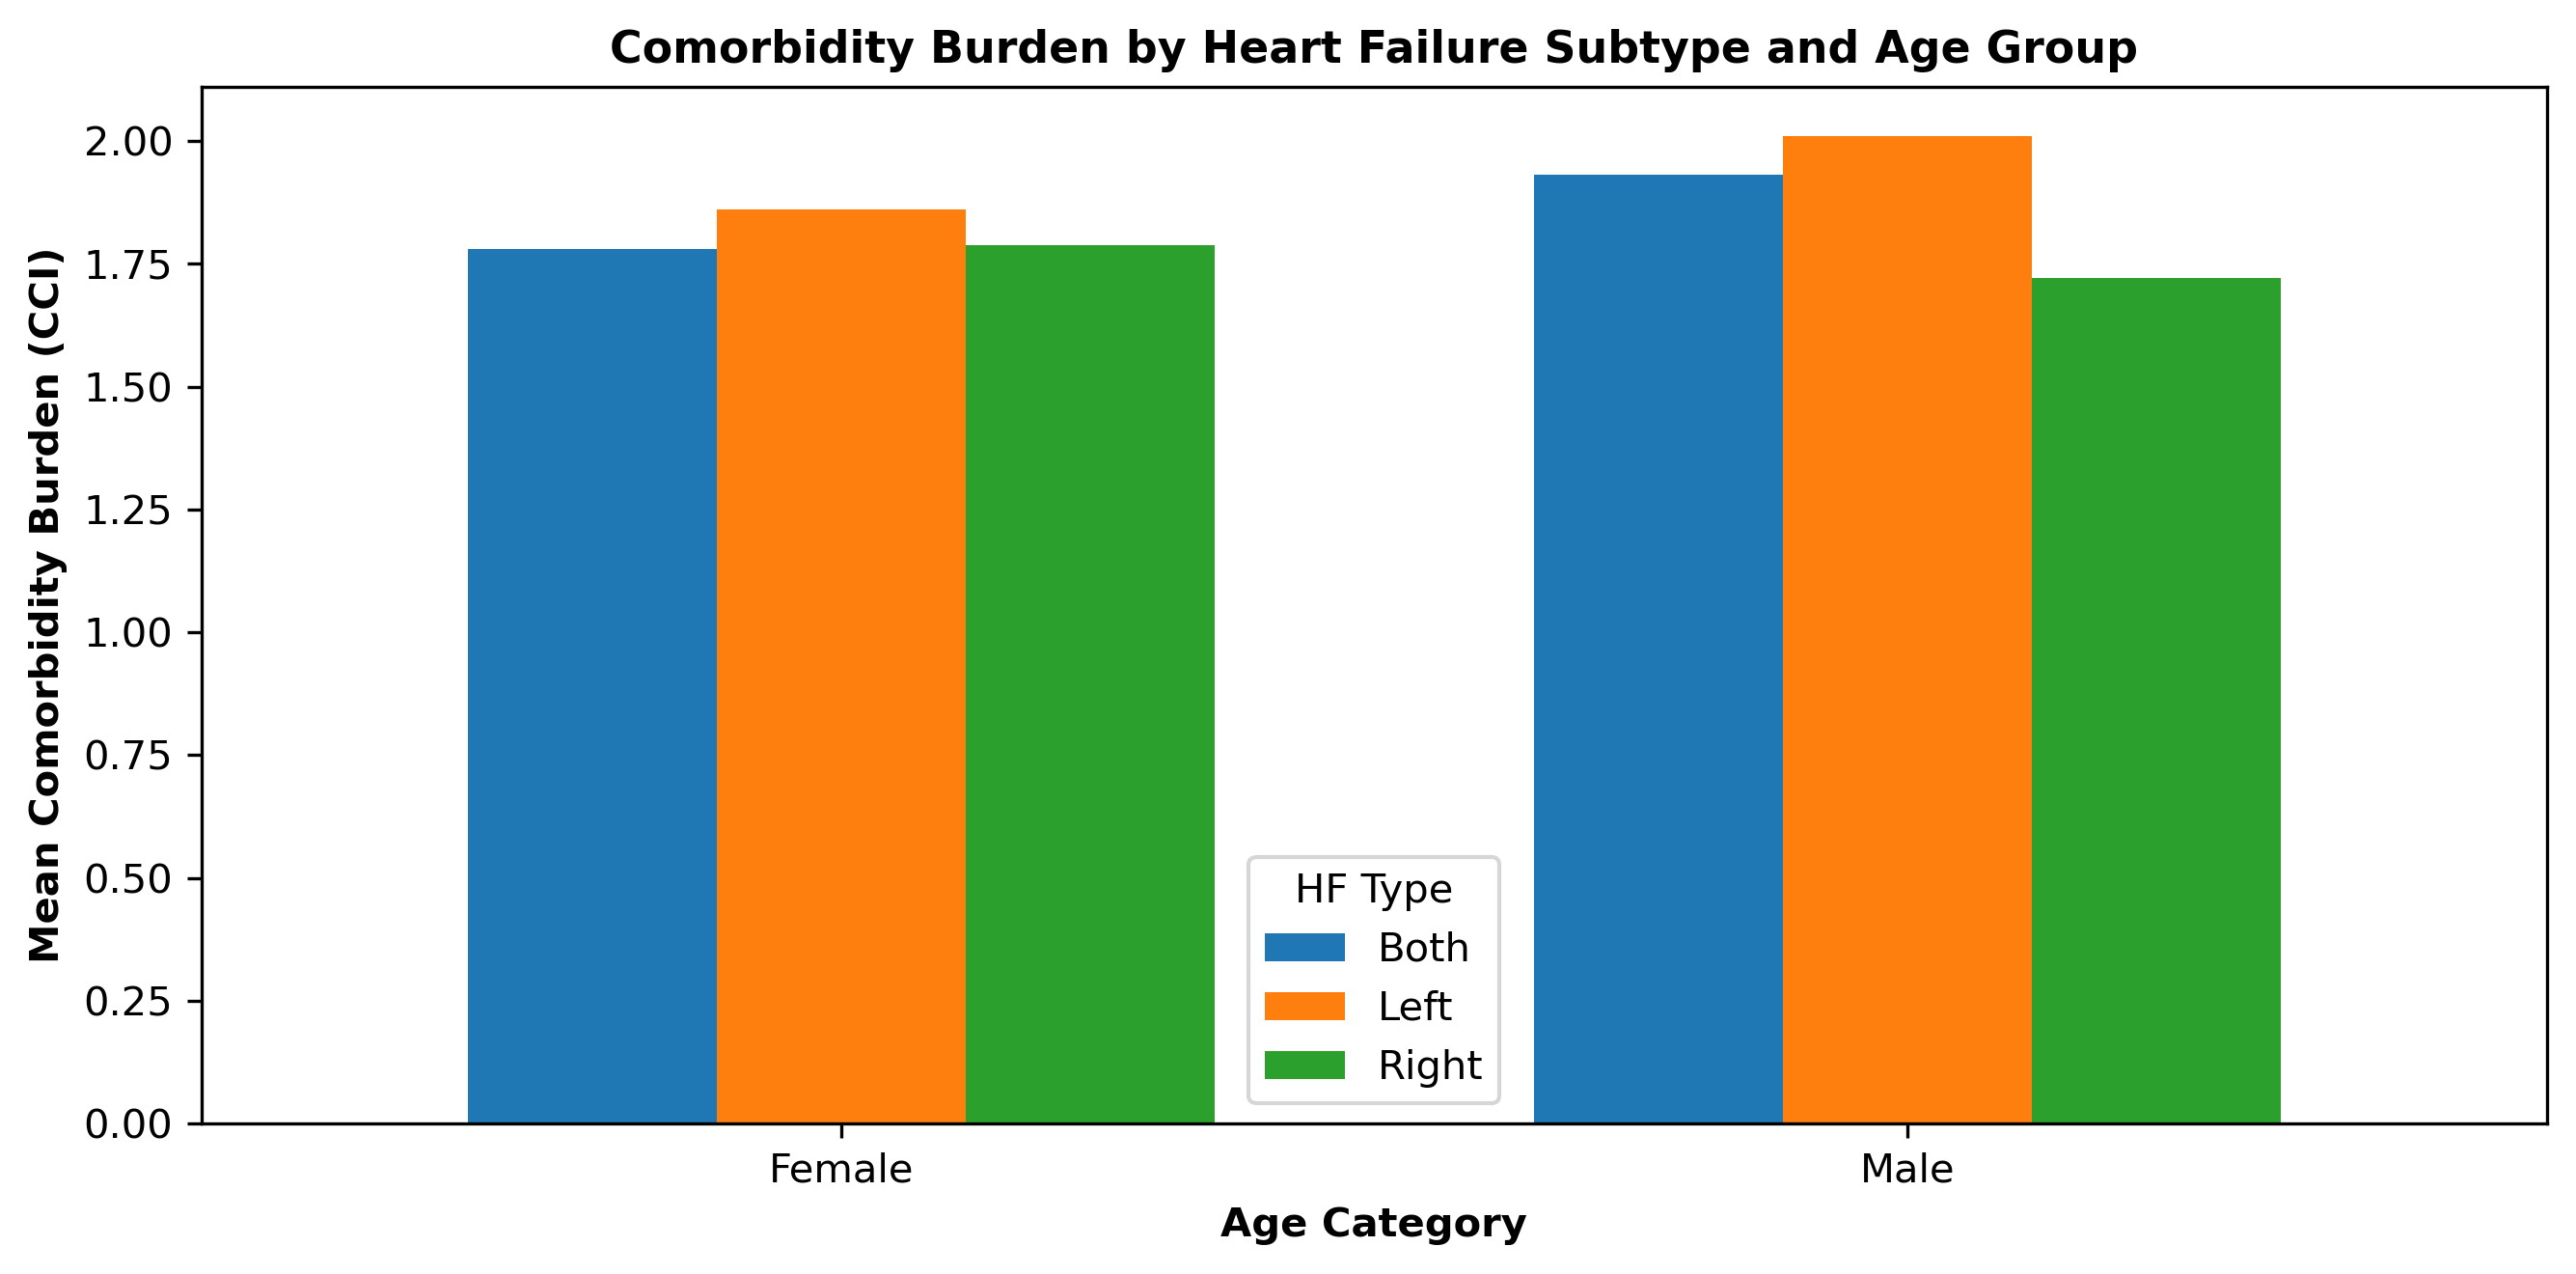

In [10]:
q8_data = (
    df.groupby(['gender', 'type_of_heart_failure'])['cci_score']
    .mean()
    .unstack()
)

# 1. Create figure and set DPI here
plt.figure(figsize=(9, 4.5), dpi=300)

# 2. Plot without passing dpi inside .plot()
ax = q8_data.plot(kind='bar', width=0.7, ax=plt.gca())

plt.title(
    'Comorbidity Burden by Heart Failure Subtype and Age Group',
    fontsize=11,
    fontweight='bold',
)
plt.xlabel('Age Category', fontweight='bold')
plt.ylabel('Mean Comorbidity Burden (CCI)', fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='HF Type')
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>Male patients presenting with Left Heart Failure exhibit the highest overall comorbidity burden (2.01 CCI), whereas female comorbidity burden is highest in Left Heart Failure as well (1.86 CCI), but with lower overall variation across failure types.

<p style="font-family: Cambria; font-size: 16px;"><b>Prescriptive Action:</b></p>Mandate comprehensive multi-organ subspecialty screening specifically for male patients admitted with isolated Left Heart Failure.